In [2]:
from time import perf_counter
import pandas as pd
from ergochemics.standardize import hash_compound
from hydra import compose, initialize
from pathlib import Path
from equilibrator_assets.local_compound_cache import LocalCompoundCache
from itertools import accumulate

100%|█████████████████████████████████████| 68.6M/68.6M [00:00<00:00, 41.5GB/s]


In [3]:
lc = LocalCompoundCache()
lc.load_cache(Path("../artifacts/.cache/equilibrator/compounds.sqlite"))

Loading compounds from ../artifacts/.cache/equilibrator/compounds.sqlite


In [4]:
compound_df = pd.DataFrame(
    data=[
        ["OC(=O)C1=CC(NC(=O)C2=CC=CC=C2)=C(O)C=C1", "3B4HA", "3-Benzamido-4-hydroxybenzoic acid"],
        ["NC1=C(O)C=CC(=C1)C(O)=O", "3A4HA", "3-Amino-4-hydroxybenzoic acid"]
    ],
    columns=["struct","coco_id", "name"]
)

lc.add_compounds(compound_df, mol_format="smiles")
# added compound has the ID 3B4HA that can be access as coco:3B4HA
# and prints as 3-Amino-4-hydroxybenzoic acid in plots
cpd_results = lc.get_compounds(["OC(=O)C1=CC(NC(=O)C2=CC=CC=C2)=C(O)C=C1"])

In [5]:
cpd_results

[GenerateCompoundResult(structure='OC(=O)C1=CC(NC(=O)C2=CC=CC=C2)=C(O)C=C1', compound=Compound(id=694325, inchi_key=RKCVLDMDZASBEO-UHFFFAOYSA-N), inchi_key='RKCVLDMDZASBEO-UHFFFAOYSA-N', method='database', status='valid')]

In [6]:
kcs = pd.read_parquet("../artifacts/known/known_compounds.parquet")
kcs.head()

,id,smiles,name,chebi_id,n_atoms
0,df58248c414f342c81e056b40bee12d17a08bf61,*,A,CHEBI:13193,1
1,bc2f74c22f98f7b6ffbc2f67453dbfa99bce9a32,**,RX,CHEBI:17792,2
2,e8ecd17bfc980925ff0b634bd13104c09dc4591f,*C,an alkane,CHEBI:18310,2
3,b219689f21c828e7f057ef453af1187baa98fbf3,*C#N,a nitrile,CHEBI:18379,3
4,94295b0379859ca57b86c85b0768526c711fe762,*C(*)(O)C(*)(*)O,an ethanediol,CHEBI:140594,8


In [7]:
kcs = kcs.loc[~kcs['smiles'].str.contains('\*')]
print(len(kcs))

9470


<>:1: SyntaxWarning: invalid escape sequence '\*'
<>:1: SyntaxWarning: invalid escape sequence '\*'
/tmp/ipykernel_106299/138490410.py:1: SyntaxWarning: invalid escape sequence '\*'
  kcs = kcs.loc[~kcs['smiles'].str.contains('\*')]


In [8]:
scl = 2
n_chunks = 10
chunk_sizes = [scl**(i) for i in range(n_chunks)]
print(chunk_sizes)
print(sum(chunk_sizes))
print(list(accumulate(chunk_sizes)))
idxs = [0] + list(accumulate(chunk_sizes))

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
1023
[1, 3, 7, 15, 31, 63, 127, 255, 511, 1023]


In [9]:
def time_add_cpds_eq(df, idxs, lc):
    times = []
    for i in range(len(idxs)-1):
        start = perf_counter()
        chunk = df.iloc[idxs[i]:idxs[i+1]][['smiles', 'id', 'name']]
        chunk.columns = ['struct', 'coco_id', 'name']
        lc.add_compounds(chunk, mol_format="smiles")
        end = perf_counter()
        times.append(end - start)
        print(f"Added {idxs[i+1]-idxs[i]} compounds in {end - start:.2f} seconds")
    return times

In [10]:
times = time_add_cpds_eq(kcs, idxs, lc)

Added 1 compounds in 2.41 seconds


One or more compounds were unable to be decomposed


Added 2 compounds in 2.49 seconds


*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
One or more compounds were unable to be decomposed


Added 4 compounds in 3.60 seconds


...

Added 128 compounds in 71.17 seconds


*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI c

Added 256 compounds in 157.11 seconds


*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI code
  #1 :Omitted undefined stereo
*** Open Babel Warning  in InChI c

Added 512 compounds in 367.22 seconds


In [12]:
import matplotlib.pyplot as plt

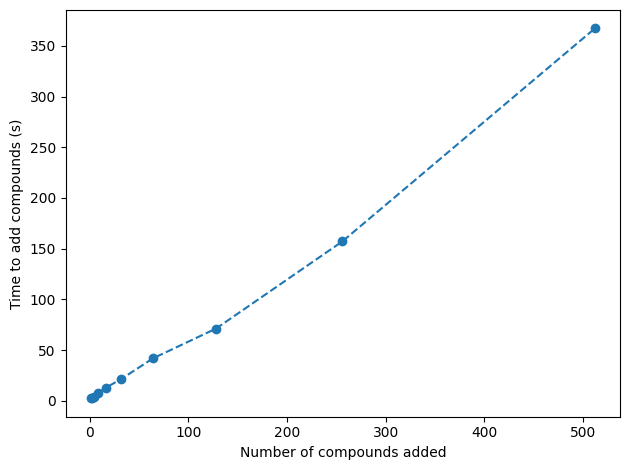

In [16]:
fig, ax = plt.subplots()
ax.plot(chunk_sizes, times, marker='o', ls='--')
ax.set_ylabel("Time to add compounds (s)")
ax.set_xlabel("Number of compounds added")
plt.tight_layout()
plt.savefig("../artifacts/time_add_cpds_eq.svg")
plt.show()